# Activity - Estimating Lifetime

From `6_regression.ipynb`: build a Kaplan-Meier survival analysis on the Telco churn
data and compare lifetime between payment methods.

The sections follow the ten-step workflow in Kim & Kim, *Survival Analysis 101: An Easy
Start Guide to Analyzing Time-to-Event Data*, European Journal of Cardiovascular Nursing.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test
from lifelines.utils import restricted_mean_survival_time

pd.set_option("display.precision", 3)

df = pd.read_csv("Telco-Churn.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 1. Identify the event

The event is churn: the customer cancels the service. `Churn` records it as yes/no, and
there is only one kind of ending in this data - nobody dies, moves abroad or gets
transferred to another product - so there are no competing risks to separate out.

## 2. Determine the follow-up duration

`tenure` is the follow-up clock: months elapsed since the customer joined, counted up to
the moment the data was collected.

In [2]:
print(f"tenure: {df['tenure'].min()} to {df['tenure'].max()} months, "
      f"{df['tenure'].nunique()} distinct values")
print(f"one row per customer: {df['customerID'].nunique()} ids across {len(df)} rows")

tenure: 0 to 72 months, 73 distinct values
one row per customer: 7043 ids across 7043 rows


So every survival curve below stops at **month 72** - a six-year window with no month
missing inside it, and no customer counted twice.

## 3. Select the time scale

Months, because that is the only scale the data offers - `tenure` arrives already rounded
to whole months, so a finer scale cannot be recovered and a coarser one would throw away
the early churn that all the action is in.

## 4. Organize the data structure

Two variables have to exist: a failure indicator coded 0/1, and the duration. A
Kaplan-Meier estimate is fed three things: how long each subject was observed, whether
that time ended in the event, and which group they are in.

| survival term | Telco column | why this one |
|---|---|---|
| duration $T$ | `tenure` | the only column measuring elapsed time, in months |
| event $E$ | `Churn == "Yes"` | whether the time ended in churn, or is still running |
| group | `PaymentMethod` | what the activity asks to compare |
| - | `customerID` | not a variable, just a check that one row means one customer |

The other seventeen are customer attributes, and a Kaplan-Meier curve has nowhere to put
them.

In [3]:
df["T"] = df["tenure"].astype(float)
df["E"] = (df["Churn"] == "Yes").astype(int)

WORKING = ["customerID", "PaymentMethod", "tenure", "Churn", "T", "E"]
df[WORKING].head()

,customerID,PaymentMethod,tenure,Churn,T,E
0,7590-VHVEG,Electronic check,1,No,1.0,0
1,5575-GNVDE,Mailed check,34,No,34.0,0
2,3668-QPYBK,Mailed check,2,Yes,2.0,1
3,7795-CFOCW,Bank transfer (automatic),45,No,45.0,0
4,9237-HQITU,Electronic check,2,Yes,2.0,1


## 5. Declare the survival data

In Stata this is the `stset` command, which stamps the dataset as survival data once and
for all. lifelines has no such step - every fitter takes the durations and the event
indicator as arguments - so what belongs here instead is the one row type that cannot be
declared at all: a customer observed for zero months.

In [4]:
print(f"tenure == 0: {(df['T'] == 0).sum()} rows (signed up too recently to be observed)")

# A zero-length observation never enters the risk set for any month, so it carries no
# information for the estimator and lifelines warns about it.
df = df[df["T"] > 0].copy()
print(f"kept {len(df)} rows")

tenure == 0: 11 rows (signed up too recently to be observed)
kept 7032 rows


## 6. Examine descriptive statistics

The point of Kaplan-Meier: most rows are *censored*, not observed failures. Averaging
`tenure` would treat "still here after 60 months" as a lifetime of 60, which understates
every group.

In [5]:
print(f"customers        {len(df)}")
print(f"churned (events) {df.E.sum()}  ({df.E.mean():.1%})")
print(f"still active     {(1 - df.E).sum()}  (right-censored)")

customers        7032
churned (events) 1869  (26.6%)
still active     5163  (right-censored)


### Life table

`event_table` is the life table the workflow asks for. Each row is one month: how many
customers were at risk, how many churned, and how many left the risk set without
churning because the data ran out on them.

In [6]:
life_table = KaplanMeierFitter().fit(df["T"], df["E"]).event_table
life_table.head(12)

,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.0,0,0,0,7032,7032
1.0,613,380,233,0,7032
2.0,238,123,115,0,6419
3.0,200,94,106,0,6181
4.0,176,83,93,0,5981
5.0,133,64,69,0,5805
6.0,110,40,70,0,5672
7.0,131,51,80,0,5562
8.0,123,42,81,0,5431


## 7. Estimate the survival curve

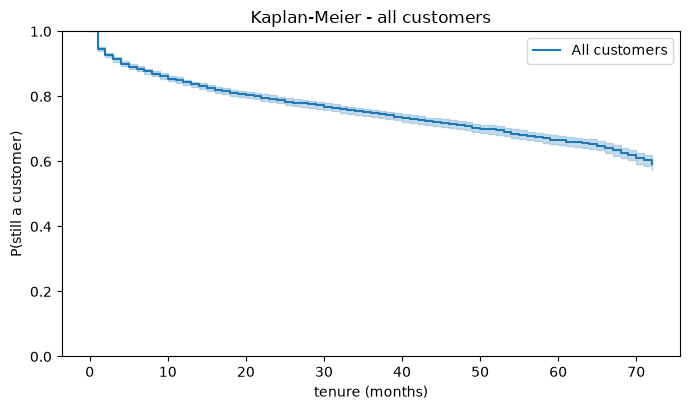

median survival time: inf
12    0.843
24    0.789
48    0.709
72    0.593
Name: All customers, dtype: float64


In [7]:
kmf = KaplanMeierFitter().fit(df["T"], event_observed=df["E"], label="All customers")

ax = kmf.plot_survival_function(figsize=(7, 4.2))
ax.set(xlabel="tenure (months)", ylabel="P(still a customer)",
       title="Kaplan-Meier - all customers", ylim=(0, 1))
plt.tight_layout()
plt.show()

print("median survival time:", kmf.median_survival_time_)
print(kmf.survival_function_at_times([12, 24, 48, 72]).round(3))

## 8. Compare the groups

One curve per payment method, with the number still at risk printed underneath and the
log-rank result on the panel - the reporting checklist the paper gives for a survival
graph.

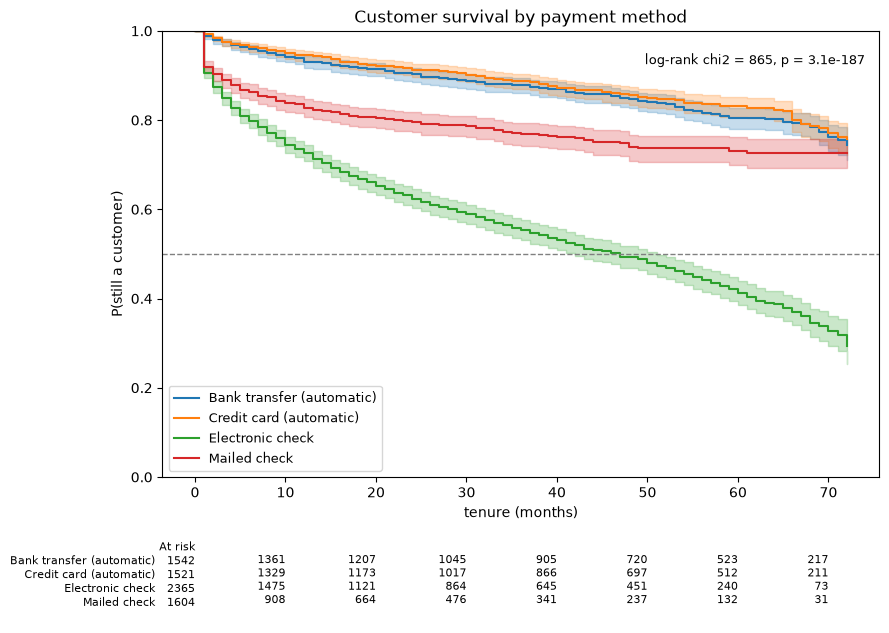

In [8]:
METHODS = sorted(df["PaymentMethod"].unique())
fitters = {}

fig, ax = plt.subplots(figsize=(9, 6.5))
for method in METHODS:
    group = df[df["PaymentMethod"] == method]
    f = KaplanMeierFitter().fit(group["T"], event_observed=group["E"], label=method)
    fitters[method] = f
    f.plot_survival_function(ax=ax, ci_show=True)

overall = multivariate_logrank_test(df["T"], df["PaymentMethod"], df["E"])
ax.set(xlabel="tenure (months)", ylabel="P(still a customer)",
       title="Customer survival by payment method", ylim=(0, 1))
ax.axhline(0.5, color="grey", lw=1, ls="--")
ax.legend(loc="lower left", fontsize=9)
ax.text(0.98, 0.95, f"log-rank chi2 = {overall.test_statistic:.0f}, p = {overall.p_value:.1e}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9)

add_at_risk_counts(*fitters.values(), ax=ax, fontsize=8, rows_to_show=["At risk"])

plt.tight_layout()
Path("figures").mkdir(exist_ok=True)
fig.savefig("figures/km_by_payment_method.png", dpi=150, bbox_inches="tight")
plt.show()

### Is the difference real?

The log-rank test compares the curves without assuming any shape for them.

In [9]:
print(f"all four groups: chi2 = {overall.test_statistic:.1f}, p = {overall.p_value:.3g}")
print()

pairwise = pairwise_logrank_test(df["T"], df["PaymentMethod"], df["E"])
pairwise.summary[["test_statistic", "p"]].round(4)

all four groups: chi2 = 865.2, p = 3.07e-187



test_statistic      p
Bank transfer (automatic) Credit card (automatic)           0.868  0.351
                          Electronic check                510.035  0.000
                          Mailed check                     51.072  0.000
Credit card (automatic)   Electronic check                539.740  0.000
                          Mailed check                     64.815  0.000
Electronic check          Mailed check                    152.456  0.000

### How much lifetime separates them

`median_survival_time_` is the statistic the lecture uses, but three of the four curves
never reach 0.5 inside the 72 months observed, so it comes back as `inf` for them. Two
statistics that do exist for every group:

- **survival at fixed times** - the share still subscribed at 12, 24, 48, 72 months
- **RMST** (restricted mean survival time) - the area under the curve up to a chosen
  horizon, read as "expected months as a customer during the first N"

RMST needs that horizon picked by hand, and the choice is not neutral: over a short
window everybody survives most of it, so the groups look closer together. Reporting
several horizons keeps that visible. Twelve months is the one to quote - the counts under
the graph above are still deep there, where by month 72 they are down to a handful.

In [10]:
HORIZONS = [12, 24, 48, 72]
HEADLINE = 12

rows = []
for method, f in fitters.items():
    s = f.survival_function_at_times(HORIZONS).to_numpy()
    row = {
        "n": int(f.event_observed.shape[0]),
        "churned": int(f.event_observed.sum()),
        "median": f.median_survival_time_,
    }
    row |= {f"S({h})": v for h, v in zip(HORIZONS, s)}
    row |= {f"RMST({h})": restricted_mean_survival_time(f, t=h) for h in HORIZONS}
    rows.append({"PaymentMethod": method} | row)

summary = pd.DataFrame(rows).set_index("PaymentMethod").sort_values(f"RMST({HEADLINE})")
summary

,n,churned,median,S(12),S(24),S(48),S(72),RMST(12),RMST(24),RMST(48),RMST(72)
PaymentMethod,,,,,,,,,,,
Electronic check,2365,1071,47.0,0.727,0.624,0.493,0.295,9.863,17.952,31.320,41.243
Mailed check,1604,308,inf,0.828,0.797,0.740,0.726,10.545,20.277,38.805,56.363
Bank transfer (automatic),1542,258,inf,0.931,0.902,0.847,0.745,11.561,22.578,43.610,63.000
Credit card (automatic),1521,232,inf,0.945,0.913,0.855,0.758,11.623,22.776,44.055,63.811


In [11]:
# How much of each horizon does a customer of this group actually spend subscribed?
share = pd.DataFrame({
    f"{h} mo": summary[f"RMST({h})"] / h for h in HORIZONS
})
share.loc["gap (best - worst)"] = share.max() - share.min()
share

,12 mo,24 mo,48 mo,72 mo
PaymentMethod,,,,
Electronic check,0.822,0.748,0.653,0.573
Mailed check,0.879,0.845,0.808,0.783
Bank transfer (automatic),0.963,0.941,0.909,0.875
Credit card (automatic),0.969,0.949,0.918,0.886
gap (best - worst),0.147,0.201,0.265,0.313


## 9. Multivariate model - Cox proportional hazards

The curves above compare payment methods without holding anything else constant, and
payment method is not chosen at random - it travels with contract type.

In [12]:
pd.crosstab(df["PaymentMethod"], df["Contract"], normalize="index").round(3)

Contract,Month-to-month,One year,Two year
PaymentMethod,,,
Bank transfer (automatic),0.382,0.254,0.364
Credit card (automatic),0.357,0.262,0.381
Electronic check,0.782,0.147,0.071
Mailed check,0.557,0.209,0.234


Electronic-check customers are on month-to-month contracts 78% of the time against 36%
for credit card, so the lifetime gap above could be contract type in disguise. A Cox
model holds contract constant and separates the two.

The coefficients are read as **hazard ratios**, `exp(coef)`: the multiplier on the
instantaneous churn rate relative to the reference level, at every point in time. HR = 2
means twice the churn rate of the reference; HR = 1 means no difference.

Reference levels: credit card (automatic), two-year contract.

In [13]:
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

REFERENCE = ["PaymentMethod_Credit card (automatic)", "Contract_Two year"]

design = pd.get_dummies(df[["PaymentMethod", "Contract"]], dtype=float).drop(columns=REFERENCE)
design["tenure"] = df["T"].to_numpy()
design["churned"] = df["E"].to_numpy()

payment_cols = [c for c in design.columns if c.startswith("PaymentMethod")]
design.head()

,PaymentMethod_Bank transfer (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Contract_Month-to-month,Contract_One year,tenure,churned
0,0.0,1.0,0.0,1.0,0.0,1.0,0
1,0.0,0.0,1.0,0.0,1.0,34.0,0
2,0.0,0.0,1.0,1.0,0.0,2.0,1
3,1.0,0.0,0.0,0.0,1.0,45.0,0
4,0.0,1.0,0.0,1.0,0.0,2.0,1


### Model A - payment method alone

In [14]:
cox_a = CoxPHFitter().fit(design[payment_cols + ["tenure", "churned"]], "tenure", "churned")

cox_a.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]

,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,
PaymentMethod_Bank transfer (automatic),1.089,0.912,1.301,3.446e-01
PaymentMethod_Electronic check,4.621,4.005,5.332,1.130e-97
PaymentMethod_Mailed check,2.149,1.810,2.551,2.540e-18


### Model B - payment method adjusted for contract type

In [15]:
cox_b = CoxPHFitter().fit(design, "tenure", "churned")

print(f"concordance  model A {cox_a.concordance_index_:.3f}   model B {cox_b.concordance_index_:.3f}")
cox_b.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]

concordance  model A 0.676   model B 0.809


,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,
PaymentMethod_Bank transfer (automatic),1.028,0.861,1.228,7.593e-01
PaymentMethod_Electronic check,2.104,1.822,2.430,3.981e-24
PaymentMethod_Mailed check,1.848,1.555,2.197,3.447e-12
Contract_Month-to-month,54.102,39.712,73.706,3.566e-141
Contract_One year,6.888,4.944,9.598,4.068e-30


In [16]:
comparison = pd.DataFrame({
    "HR alone (A)": cox_a.hazard_ratios_,
    "HR adjusted (B)": cox_b.hazard_ratios_[payment_cols],
})
comparison["shrinkage"] = 1 - comparison["HR adjusted (B)"] / comparison["HR alone (A)"]
comparison

,HR alone (A),HR adjusted (B),shrinkage
covariate,,,
PaymentMethod_Bank transfer (automatic),1.089,1.028,0.056
PaymentMethod_Electronic check,4.621,2.104,0.545
PaymentMethod_Mailed check,2.149,1.848,0.140


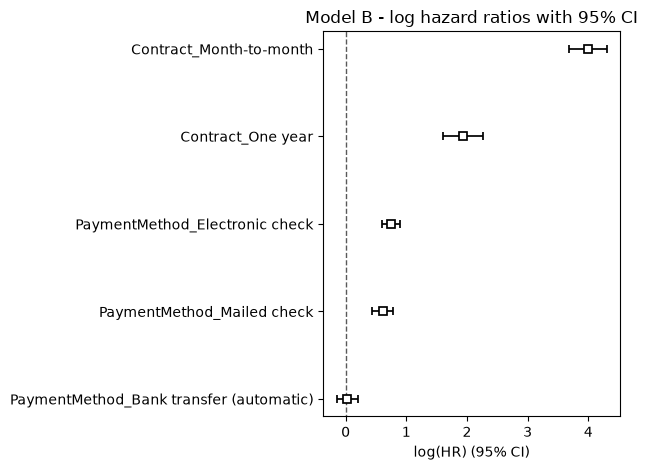

In [17]:
ax = cox_b.plot()
ax.set_title("Model B - log hazard ratios with 95% CI")
plt.tight_layout()
plt.savefig("figures/cox_hazard_ratios.png", dpi=150, bbox_inches="tight")
plt.show()

### Does the model's own assumption hold?

Cox assumes a covariate's hazard ratio is *constant over time*. That is testable, and
here it fails for some covariates - so each HR above should be read as an average effect
across the 72 months, not a fixed multiplier. The mailed-check curve in section 8 shows
why: it drops steeply in the first months and then flattens.

In [18]:
proportional_hazard_test(cox_b, design, time_transform="rank").summary[["test_statistic", "p"]]

,test_statistic,p
Contract_Month-to-month,20.686,5.411e-06
Contract_One year,0.008,9.286e-01
PaymentMethod_Bank transfer (automatic),0.303,5.821e-01
PaymentMethod_Electronic check,9.082,2.582e-03
PaymentMethod_Mailed check,30.595,3.180e-08


## 10. Interpret and report

### Minimum follow-up time

Two different questions hide under "how long do we need to watch customers".

**How soon can a conclusion be drawn?** Censor every customer administratively at month
`t` - as if the study had stopped there - and re-run the log-rank test. The smallest `t`
whose test comes back significant is the minimum follow-up that particular comparison
needs.

**How long do the estimates stay trustworthy?** A survival curve is only as good as the
number of customers still at risk behind it. Once the risk set thins out, the curve is
carried by a handful of people and the confidence band widens accordingly.

In [19]:
FOLLOWUPS = range(1, 25)
T_all, E_all, G_all = df["T"].to_numpy(), df["E"].to_numpy(), df["PaymentMethod"].to_numpy()

first_significant = {}
for t in FOLLOWUPS:
    censored_T = np.minimum(T_all, t)
    censored_E = ((E_all == 1) & (T_all <= t)).astype(int)
    for pair, p in pairwise_logrank_test(censored_T, G_all, censored_E).summary["p"].items():
        if pair not in first_significant and p < 0.05:
            first_significant[pair] = (t, p)

full = pairwise_logrank_test(T_all, G_all, E_all).summary["p"]
rows = []
for pair in full.index:
    t, p = first_significant.get(pair, (np.nan, np.nan))
    rows.append({"pair": " vs ".join(pair),
                 "min follow-up (months)": t,
                 "p at that point": p,
                 "p on full 72 months": full[pair]})

pd.DataFrame(rows).sort_values("min follow-up (months)").set_index("pair")

,min follow-up (months),p at that point,p on full 72 months
pair,,,
Bank transfer (automatic) vs Electronic check,1.0,5.673e-25,6.231e-113
Bank transfer (automatic) vs Mailed check,1.0,1.930e-19,8.905e-13
Credit card (automatic) vs Electronic check,1.0,1.765e-28,2.148e-119
Credit card (automatic) vs Mailed check,1.0,4.866e-23,8.226e-16
Electronic check vs Mailed check,2.0,5.579e-03,5.038e-35
Bank transfer (automatic) vs Credit card (automatic),NaN,NaN,3.514e-01


In [20]:
at_risk = pd.DataFrame({
    method: [(group["T"] >= t).mean() for t in (12, 24, 36, 48, 60, 72)]
    for method, group in df.groupby("PaymentMethod")
}, index=[f"t={t}" for t in (12, 24, 36, 48, 60, 72)]).T
at_risk.columns.name = "fraction still at risk"
at_risk

fraction still at risk,t=12,t=24,t=36,t=48,t=60,t=72
Bank transfer (automatic),0.871,0.748,0.627,0.507,0.355,0.104
Credit card (automatic),0.863,0.748,0.621,0.500,0.347,0.095
Electronic check,0.605,0.440,0.311,0.210,0.113,0.017
Mailed check,0.553,0.372,0.252,0.165,0.087,0.011


### Findings

In [21]:
best, worst = summary.index[-1], summary.index[0]

print(f"longest-lived group   {best}")
print(f"shortest-lived group  {worst}")
print()
for h in HORIZONS:
    b, w = summary.loc[best, f"RMST({h})"], summary.loc[worst, f"RMST({h})"]
    print(f"over {h:>2} months: {b:5.2f} vs {w:5.2f}  ->  gap {b - w:5.2f} months ({(b - w) / h:.1%} of the window)")
print()
print(f"electronic-check hazard ratio, unadjusted        {cox_a.hazard_ratios_['PaymentMethod_Electronic check']:.2f}")
print(f"electronic-check hazard ratio, given contract    {cox_b.hazard_ratios_['PaymentMethod_Electronic check']:.2f}")

longest-lived group   Credit card (automatic)
shortest-lived group  Electronic check

over 12 months: 11.62 vs  9.86  ->  gap  1.76 months (14.7% of the window)
over 24 months: 22.78 vs 17.95  ->  gap  4.82 months (20.1% of the window)
over 48 months: 44.05 vs 31.32  ->  gap 12.73 months (26.5% of the window)
over 72 months: 63.81 vs 41.24  ->  gap 22.57 months (31.3% of the window)

electronic-check hazard ratio, unadjusted        4.62
electronic-check hazard ratio, given contract    2.10


**Lifetime by payment method.** Over a first year, a credit-card customer spends 11.6 of
the 12 months subscribed against 9.9 for an electronic-check customer - 97% of the window
versus 82%. The two automatic methods cannot be told apart at all: the log-rank test
gives p = 0.35 on the full data, and it never falls below 0.05 at any follow-up horizon.
Mailed check sits between them. Median survival time, the statistic the lecture uses,
only exists for electronic check (47 months) because the other three curves never fall
to 0.5, so RMST does the comparing here.

**The gap grows with the window.** It is 1.8 months over a year, 12.7 months over four
years, 22.6 months over the full six - and as a share of the window it climbs from 15% to
31%. So a single horizon flatters or exaggerates depending on where it is cut. Twelve
months is the honest one to quote because the risk set is still full there; the longer
figures are real but rest on a thinning tail.

**How much of that is the payment method itself.** On its own, electronic check carries
a hazard ratio of 4.6 against credit card. Once contract type is held constant it falls
to about 2.1 - so roughly half the apparent effect was contract type wearing a payment
method's clothes. What is left is still a doubled churn rate, and mailed check behaves
much the same way once adjusted, which points at the manual methods themselves rather
than at who chooses them.

**Minimum follow-up.** Every comparison the data can support is already significant after
**2 months** of follow-up: four of the five pairs separate within the first month, and
electronic check versus mailed check needs a second. Watching longer sharpens the
estimates but changes no conclusion - except for automatic bank transfer versus credit
card, which stays indistinguishable however long anyone waits. At the other end, the two
manual-payment groups are down to 9-11% still at risk by month 60, so the tail of those
curves should not be quoted.